In [1]:
import dpluspy
import demes 
import moments 
import msprime
import numpy as np
import pandas
import scipy

In [2]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=9)
matplotlib.rc("ytick", labelsize=9)
matplotlib.rc("axes", labelsize=9)
matplotlib.rc("axes", titlesize=9)
matplotlib.rc("legend", fontsize=7)
plt.rcParams['legend.title_fontsize'] = 'small'

In [3]:
# Merge replicate tables together
trial_tbls = []
for ii in range(100):
    try:
        _tbl = pandas.read_csv(f"trials/sym_mig_LRT_results_rep{ii}.csv")
        trial_tbls.append(_tbl)
    except:
        print(f"missing trial {ii}")
tbl = pandas.concat(trial_tbls)

print(len(tbl))
print(tbl.columns)

missing trial 6
missing trial 18
missing trial 37
missing trial 41
missing trial 92
95
Index(['D_naive', 'p_naive', 'D_simple', 'p_simple', 'D_complex', 'p_complex',
       'sN_A', 'sT_XY', 'sN_X', 'sN_Y', 'sm_XY', 'cN_A', 'cT_XY', 'cN_X',
       'cN_Y', 'cm_X_Y', 'cm_Y_X'],
      dtype='object')


Text(0.5, 1.0, 'LR test statistic for symmetric/asymmetric $m$ IM models')

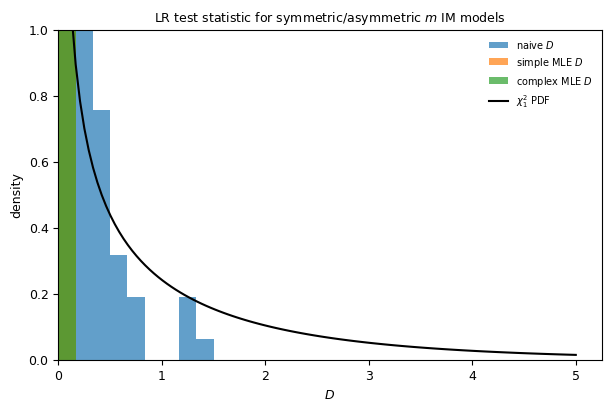

In [4]:
# Plot LRT statistics
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")

bins = np.linspace(0, 5, 31)
plt.hist(tbl["D_naive"], bins=bins, color="tab:blue", label="naive $D$",
    density=True, alpha=0.7)
plt.hist(tbl["D_simple"], bins=bins, color="tab:orange", 
    label="simple MLE $D$", density=True, alpha=0.7)
plt.hist(tbl["D_complex"], bins=bins, color="tab:green", 
    label="complex MLE $D$", density=True, alpha=0.7)

# Plot the chi2 distribution with 1 df (the asymptotic null distribution)
df = 1
xx = np.linspace(0, 5, 120)
yy = scipy.stats.chi2.pdf(xx, df)
plt.plot(xx, yy, color="black", label=r"$\chi^2_1$ PDF")

ax.set_ylim(0, 1)
ax.set_xlim(0, )
ax.set_ylabel("density")
ax.set_xlabel("$D$")
ax.legend(framealpha=0)
ax.set_title("LR test statistic for symmetric/asymmetric $m$ IM models")

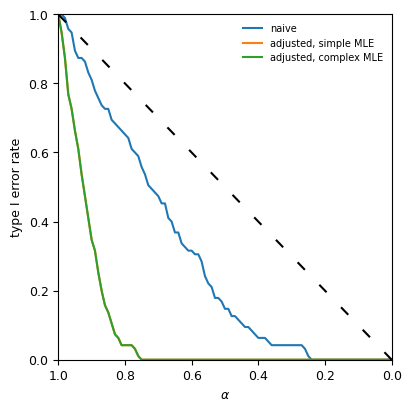

In [5]:
# Plot type I error rates
fig, ax = plt.subplots(figsize=(4, 4), layout="constrained")

p_naive = np.array(tbl["p_naive"])
p_simple = np.array(tbl["p_simple"])
p_complex = np.array(tbl["p_complex"])

alphas = np.linspace(0, 1, 101)
naive_error = np.array([np.count_nonzero(p_naive < a) / len(p_naive) 
    for a in alphas])
plt.plot(alphas, naive_error, color="tab:blue", label="naive")

simple_error = np.array([np.count_nonzero(p_simple < a) / len(p_simple) 
    for a in alphas])
plt.plot(alphas, simple_error, color="tab:orange", 
    label="adjusted, simple MLE")

complex_error = np.array([np.count_nonzero(p_complex < a) / len(p_complex) 
    for a in alphas])
plt.plot(alphas, complex_error, color="tab:green", 
    label="adjusted, complex MLE")

ax.plot([0, 1], [0, 1], color="black", linestyle=(0, (5, 10)))
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)
ax.set_ylabel("type I error rate")
ax.set_xlabel(r"$\alpha$")
ax.invert_xaxis()
ax.legend(framealpha=0)